In [1]:
# ============================================================
# Cell 1: Top-level imports + module reload
# ============================================================

import re
import gc
import json
import time
import random
import hashlib
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import torch
except ImportError:
    torch = None

import config
import metrics
import model_loader
import modes
import workloads
import runner
import benchmark_modes
import reporter

for module in [
    config,
    metrics,
    model_loader,
    modes,
    workloads,
    runner,
    benchmark_modes,
    reporter,
]:
    importlib.reload(module)

from config import CONFIG, RAW_RESULTS_DIR, BENCHMARK_DATA_DIR
from modes import build_runtime_mode_by_name
from workloads import (
    build_runtime_workload_by_name,
    build_runtime_workloads_for_name,
)
from runner import run_single_benchmark
from benchmark_modes import (
    save_results_json,
    save_results_csv,
    save_summary_csv,
    build_aggregate_rows,
    build_comparison_rows,
    save_aggregate_csv,
    apply_external_score_sidecar,
    annotate_results_with_baseline_similarity,
)
from reporter import generate_full_report

print("Project root:", Path.cwd())
print("RAW_RESULTS_DIR:", RAW_RESULTS_DIR)
print("BENCHMARK_DATA_DIR:", BENCHMARK_DATA_DIR)

Project root: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM
RAW_RESULTS_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw
BENCHMARK_DATA_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/benchmark_data


In [2]:
# ============================================================
# Cell 2: Notebook helpers
# ============================================================

def resolve_runtime_mode(mode_name: str):
    return build_runtime_mode_by_name(mode_name)


def resolve_runtime_workload(workload_name: str):
    match = re.fullmatch(r"(shared_prefix_chat)_v(\d+)", workload_name)
    if match:
        base_name = match.group(1)
        variant_id = int(match.group(2))
        return build_runtime_workload_by_name(
            base_name,
            repeated_prefix_variant=variant_id,
        )

    return build_runtime_workload_by_name(workload_name)


def expand_workload_group_names(workload_group_names):
    expanded = []

    for workload_name in workload_group_names:
        if re.fullmatch(r"shared_prefix_chat_v\d+", workload_name):
            expanded.append(workload_name)
            continue

        runtime_rows = build_runtime_workloads_for_name(workload_name)
        expanded.extend([row.name for row in runtime_rows])

    return list(dict.fromkeys(expanded))


def canonical_workload_group_name(expanded_workload_name: str) -> str:
    if "__" in str(expanded_workload_name):
        return str(expanded_workload_name).split("__", 1)[0]
    return str(expanded_workload_name)


def run_one(mode_name: str, workload_name: str, trial_index: int = 0):
    runtime_mode = resolve_runtime_mode(mode_name)
    runtime_workload = resolve_runtime_workload(workload_name)

    return run_single_benchmark(
        runtime_mode=runtime_mode,
        workload=runtime_workload,
        trial_index=trial_index,
    )


def fmt_num(x, decimals=2):
    if x is None or pd.isna(x):
        return "NA"
    return f"{x:.{decimals}f}"


def count_jsonl_rows(path: Path) -> int:
    if not path.exists():
        return 0

    n = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                n += 1

    return n


def preview_jsonl(path: Path, n=2):
    print("\nPreview:", path)

    if not path.exists():
        print("Missing file.")
        return

    with open(path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            if idx >= n:
                break
            print(line.strip())

In [3]:
# ============================================================
# Cell 3: Verify benchmark sidecars
# ============================================================

SIDECARE_FILES = {
    "mmlu_pro_eval": "mmlu_pro_eval.jsonl",
    "gsm8k_eval": "gsm8k_eval.jsonl",
    "truthfulqa_eval": "truthfulqa_eval.jsonl",
    "gpqa_eval": "gpqa_eval.jsonl",
    "mlu_eval": "mlu_eval.jsonl",
    "mt_bench_eval": "mt_bench_eval.jsonl",
    "alpacaeval2_lc_eval": "alpacaeval2_lc_eval.jsonl",
}

sidecar_rows = []

for group_name, filename in SIDECARE_FILES.items():
    path = BENCHMARK_DATA_DIR / filename
    sidecar_rows.append({
        "workload_group": group_name,
        "path": str(path),
        "exists": path.exists(),
        "rows": count_jsonl_rows(path),
    })

sidecar_df = pd.DataFrame(sidecar_rows)
display(sidecar_df)

missing = sidecar_df[~sidecar_df["exists"]]
if len(missing) > 0:
    raise FileNotFoundError("Missing sidecars:\n" + "\n".join(missing["path"].tolist()))

for group_name, filename in SIDECARE_FILES.items():
    preview_jsonl(BENCHMARK_DATA_DIR / filename, n=1)

,workload_group,path,exists,rows
0,mmlu_pro_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000
1,gsm8k_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000
2,truthfulqa_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,817
3,gpqa_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,546
4,mlu_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000
5,mt_bench_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,80
6,alpacaeval2_lc_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,805



Preview: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/benchmark_data/mmlu_pro_eval.jsonl
{"id": "mmlu_pro_0001", "prompt": "Question: Which of the following was not cited as evidence for life in the martian meteorite ALH84001?\nA. Amino acids with a preferred orientation or \"chirality\"\nB. Magnetite grains similar to those formed by bacteria on Earth\nC. Methane traces within the meteorite\nD. High levels of sulfur, indicating a possible volcanic origin\nE. Detection of radio signals from the meteorite\nF. Carbonate minerals indicating a thicker warmer Martian atmosphere\nG. Presence of water-ice in the meteorite\nH. Presence of olivine, a common mineral in Martian meteorites\nI. Fossilized microbial life forms within the meteorite\nJ. Complex organic molecules specifically PAHs\nAnswer with the correct letter only.", "reference": "A", "valid_labels": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"], "benchmark_suite": "mmlu_pro", "benchmark_subset": "physics", "benchmark_langua

In [4]:
# ============================================================
# Cell 4: Final sweep configuration
# ============================================================

STANDARD_DENSE_MODES = [
    "fp16_baseline",
    "gptq_4bit",
    "speculative_decoding",
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
    "prefix_caching",
    "continuous_batching",
]

BENCHMARK_DENSE_MODES = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "prefix_caching",
]

NORMAL_WORKLOAD_GROUPS = {
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat_v0",
    "shared_prefix_chat_v1",
    "memory_pressure_long_context",
}

AUTOMATIC_ACCURACY_WORKLOAD_GROUPS = {
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
}

EXTERNAL_JUDGE_WORKLOAD_GROUPS = {
    "mt_bench_eval",
    "alpacaeval2_lc_eval",
}

BENCHMARK_WORKLOAD_GROUPS = (
    AUTOMATIC_ACCURACY_WORKLOAD_GROUPS
    | EXTERNAL_JUDGE_WORKLOAD_GROUPS
)

FINAL_DENSE_WORKLOAD_GROUPS = [
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat",
    "memory_pressure_long_context",
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
    "mt_bench_eval",
    "alpacaeval2_lc_eval",
]

# Normal fixed workloads get repeated trials.
NORMAL_NUM_TRIALS = 5 # Change to 15 or 20

# Benchmark-style workloads use many unique prompts and only one generation per prompt/mode.
BENCHMARK_NUM_TRIALS = 1

# Random prompt caps per benchmark group.
# MT-Bench only has 80, so use all 80.
WORKLOAD_SAMPLE_LIMITS = {
    "mmlu_pro_eval": 5,        # Change to 500
    "gsm8k_eval": 5,           # Change to 500
    "truthfulqa_eval": 5,      # Change to 500
    "gpqa_eval": 5,            # Change to 500
    "mlu_eval": 5,             # Change to 500
    "alpacaeval2_lc_eval": 5,  # Change to 500
    "mt_bench_eval": 5,         # Change to 80
}

WORKLOAD_SAMPLE_SEED = 42

STANDARD_DENSE_MODES = list(dict.fromkeys(STANDARD_DENSE_MODES))
BENCHMARK_DENSE_MODES = list(dict.fromkeys(BENCHMARK_DENSE_MODES))
FINAL_DENSE_WORKLOAD_GROUPS = list(dict.fromkeys(FINAL_DENSE_WORKLOAD_GROUPS))

def trials_for_workload(expanded_workload_name: str) -> int:
    group_name = canonical_workload_group_name(expanded_workload_name)

    if group_name in BENCHMARK_WORKLOAD_GROUPS:
        return BENCHMARK_NUM_TRIALS

    return NORMAL_NUM_TRIALS


def modes_for_workload(expanded_workload_name: str):
    group_name = canonical_workload_group_name(expanded_workload_name)

    if group_name in BENCHMARK_WORKLOAD_GROUPS:
        return BENCHMARK_DENSE_MODES

    return STANDARD_DENSE_MODES


def sample_expanded_workloads_for_group(group_name: str):
    if group_name == "shared_prefix_chat":
        return ["shared_prefix_chat_v0", "shared_prefix_chat_v1"]

    expanded = expand_workload_group_names([group_name])
    expanded = list(dict.fromkeys(expanded))

    limit = WORKLOAD_SAMPLE_LIMITS.get(group_name)

    if limit is None or len(expanded) <= limit:
        return expanded

    stable_digest = hashlib.md5(group_name.encode("utf-8")).hexdigest()
    stable_offset = int(stable_digest[:8], 16)
    rng = random.Random(WORKLOAD_SAMPLE_SEED + stable_offset)
    sampled = rng.sample(expanded, k=limit)

    return sorted(sampled)

In [5]:
# ============================================================
# Cell 5: Expand sampled final workload plan
# ============================================================

expanded_workloads = []

for group_name in FINAL_DENSE_WORKLOAD_GROUPS:
    expanded_workloads.extend(sample_expanded_workloads_for_group(group_name))

FINAL_DENSE_WORKLOADS = list(dict.fromkeys(expanded_workloads))

TOTAL_DENSE_RUNS = sum(
    len(modes_for_workload(workload_name)) * trials_for_workload(workload_name)
    for workload_name in FINAL_DENSE_WORKLOADS
)

plan_rows = []

for workload_name in FINAL_DENSE_WORKLOADS:
    group_name = canonical_workload_group_name(workload_name)

    for mode_name in modes_for_workload(workload_name):
        plan_rows.append({
            "mode_name": mode_name,
            "workload_name": workload_name,
            "workload_group": group_name,
            "trials": trials_for_workload(workload_name),
        })

plan_df = pd.DataFrame(plan_rows)

group_plan_df = (
    plan_df
    .groupby("workload_group", as_index=False)
    .agg(
        num_expanded_workloads=("workload_name", "nunique"),
        num_modes=("mode_name", "nunique"),
        trials_per_pair=("trials", "max"),
        planned_runs=("trials", "sum"),
    )
)

print("Standard dense modes:")
for mode_name in STANDARD_DENSE_MODES:
    print(" -", mode_name)

print("\nBenchmark-safe dense modes:")
for mode_name in BENCHMARK_DENSE_MODES:
    print(" -", mode_name)

print("\nTotal expanded workloads:", len(FINAL_DENSE_WORKLOADS))
print("Total planned runs:", TOTAL_DENSE_RUNS)

display(group_plan_df)
display(plan_df.head(30))
display(plan_df.tail(30))

Standard dense modes:
 - fp16_baseline
 - gptq_4bit
 - speculative_decoding
 - gptq_plus_prefix_caching
 - int8_plus_continuous_batching
 - prefix_caching
 - continuous_batching

Benchmark-safe dense modes:
 - fp16_baseline
 - gptq_4bit
 - int8_quant
 - speculative_decoding
 - prefix_caching

Total expanded workloads: 42
Total planned runs: 420


,workload_group,num_expanded_workloads,num_modes,trials_per_pair,planned_runs
0,alpacaeval2_lc_eval,5,5,1,25
1,gpqa_eval,5,5,1,25
2,gsm8k_eval,5,5,1,25
3,long_prompt_long_output,1,7,5,35
4,long_prompt_short_output,1,7,5,35
5,memory_pressure_long_context,1,7,5,35
6,mlu_eval,5,5,1,25
7,mmlu_pro_eval,5,5,1,25
8,mt_bench_eval,5,5,1,25
9,shared_prefix_chat_v0,1,7,5,35


,mode_name,workload_name,workload_group,trials
0,fp16_baseline,short_prompt_short_output,short_prompt_short_output,5
1,gptq_4bit,short_prompt_short_output,short_prompt_short_output,5
2,speculative_decoding,short_prompt_short_output,short_prompt_short_output,5
3,gptq_plus_prefix_caching,short_prompt_short_output,short_prompt_short_output,5
4,int8_plus_continuous_batching,short_prompt_short_output,short_prompt_short_output,5
5,prefix_caching,short_prompt_short_output,short_prompt_short_output,5
6,continuous_batching,short_prompt_short_output,short_prompt_short_output,5
7,fp16_baseline,short_prompt_long_output,short_prompt_long_output,5
8,gptq_4bit,short_prompt_long_output,short_prompt_long_output,5
9,speculative_decoding,short_prompt_long_output,short_prompt_long_output,5


,mode_name,workload_name,workload_group,trials
194,fp16_baseline,mt_bench_eval__mt_bench_0065,mt_bench_eval,1
195,gptq_4bit,mt_bench_eval__mt_bench_0065,mt_bench_eval,1
196,int8_quant,mt_bench_eval__mt_bench_0065,mt_bench_eval,1
197,speculative_decoding,mt_bench_eval__mt_bench_0065,mt_bench_eval,1
198,prefix_caching,mt_bench_eval__mt_bench_0065,mt_bench_eval,1
199,fp16_baseline,alpacaeval2_lc_eval__alpacaeval2_0087,alpacaeval2_lc_eval,1
200,gptq_4bit,alpacaeval2_lc_eval__alpacaeval2_0087,alpacaeval2_lc_eval,1
201,int8_quant,alpacaeval2_lc_eval__alpacaeval2_0087,alpacaeval2_lc_eval,1
202,speculative_decoding,alpacaeval2_lc_eval__alpacaeval2_0087,alpacaeval2_lc_eval,1
203,prefix_caching,alpacaeval2_lc_eval__alpacaeval2_0087,alpacaeval2_lc_eval,1


In [6]:
# ============================================================
# Cell 6: Resolve and inspect final mode set
# ============================================================

ALL_FINAL_DENSE_MODES = list(dict.fromkeys(STANDARD_DENSE_MODES + BENCHMARK_DENSE_MODES))

resolved_dense_rows = []

for mode_name in ALL_FINAL_DENSE_MODES:
    mode = resolve_runtime_mode(mode_name)
    resolved_dense_rows.append({
        "mode_name": mode.name,
        "backend": mode.backend,
        "quantization": mode.quantization,
        "prefix_caching": mode.prefix_caching,
        "continuous_batching": mode.continuous_batching,
        "speculative_decoding": mode.speculative_decoding,
        "primary_phase": mode.primary_phase,
        "notes": mode.notes,
    })

resolved_dense_df = pd.DataFrame(resolved_dense_rows)
display(resolved_dense_df)

,mode_name,backend,quantization,prefix_caching,continuous_batching,speculative_decoding,primary_phase,notes
0,fp16_baseline,vllm,None,False,False,False,both,standard mode
1,gptq_4bit,vllm,gptq,False,False,False,decode,quantization=gptq
2,speculative_decoding,vllm,None,False,False,True,decode,speculative decoding enabled
3,gptq_plus_prefix_caching,vllm,gptq,True,False,False,both,quantization=gptq; prefix caching enabled
4,int8_plus_continuous_batching,vllm,compressed-tensors,False,True,False,decode,quantization=compressed-tensors; continuous ba...
5,prefix_caching,vllm,None,True,False,False,prefill,prefix caching enabled
6,continuous_batching,vllm,None,False,True,False,decode,continuous batching benchmark uses a multi-req...
7,int8_quant,vllm,compressed-tensors,False,False,False,decode,quantization=compressed-tensors


In [7]:
# ============================================================
# Cell 7: Execute final sweep (reuse loaded bundle per mode)
# ============================================================

from model_loader import load_model_for_mode, unload_model

dense_results = []
dense_error_rows = []

dense_run_stamp = time.strftime("%Y%m%d_%H%M%S")
dense_partial_json_path = RAW_RESULTS_DIR / f"dense_final_partial_{dense_run_stamp}.json"
dense_partial_csv_path = RAW_RESULTS_DIR / f"dense_final_partial_{dense_run_stamp}.csv"

run_counter = 0

# Build per-mode workload list so each mode is loaded once.
mode_to_workloads = {}
for mode_name in ALL_FINAL_DENSE_MODES:
    mode_to_workloads[mode_name] = [
        workload_name
        for workload_name in FINAL_DENSE_WORKLOADS
        if mode_name in modes_for_workload(workload_name)
    ]

try:
    for mode_name in ALL_FINAL_DENSE_MODES:
        runtime_mode = resolve_runtime_mode(mode_name)
        relevant_workloads = mode_to_workloads[mode_name]

        print("\n" + "#" * 120)
        print(f"LOADING MODE ONCE: {mode_name}")
        print(f"Relevant workloads: {len(relevant_workloads)}")
        print("#" * 120)

        bundle = None

        try:
            bundle = load_model_for_mode(runtime_mode)

            for workload_name in relevant_workloads:
                n_trials = trials_for_workload(workload_name)
                runtime_workload = resolve_runtime_workload(workload_name)

                print("\n" + "=" * 120)
                print(f"MODE: {mode_name}")
                print(f"WORKLOAD: {workload_name}")
                print(f"WORKLOAD GROUP: {canonical_workload_group_name(workload_name)}")
                print(f"TRIALS: {n_trials}")
                print("=" * 120)

                for trial_index in range(n_trials):
                    run_counter += 1

                    try:
                        result = run_single_benchmark(
                            runtime_mode=runtime_mode,
                            workload=runtime_workload,
                            trial_index=trial_index,
                            preloaded_bundle=bundle,
                        )

                        dense_results.append(result)

                        print(
                            f"[{run_counter}/{TOTAL_DENSE_RUNS}] "
                            f"{mode_name:28s} | {workload_name:48s} | trial={trial_index:02d} | "
                            f"success={result.success} | "
                            f"ttft={fmt_num(result.ttft_ms)} ms | "
                            f"lat={fmt_num(result.total_latency_ms)} ms | "
                            f"tps={fmt_num(result.tokens_per_second)} | "
                            f"J/tok={fmt_num(result.energy_per_token_j, 3)} | "
                            f"gpu={fmt_num(result.peak_gpu_memory_mb)} MB"
                        )

                    except KeyboardInterrupt:
                        print("\nInterrupted by user. Saving partial outputs before raising.")
                        if dense_results:
                            save_results_json(dense_results, dense_partial_json_path)
                            save_results_csv(dense_results, dense_partial_csv_path)
                            print("Partial JSON:", dense_partial_json_path)
                            print("Partial CSV:", dense_partial_csv_path)
                        raise

                    except Exception as exc:
                        dense_error_rows.append({
                            "mode_name": mode_name,
                            "workload_name": workload_name,
                            "trial_index": trial_index,
                            "error": str(exc),
                        })

                        print(
                            f"[{run_counter}/{TOTAL_DENSE_RUNS}] "
                            f"{mode_name:28s} | {workload_name:48s} | trial={trial_index:02d} | "
                            f"ERROR={exc}"
                        )

                    if run_counter % 25 == 0 and dense_results:
                        save_results_json(dense_results, dense_partial_json_path)
                        save_results_csv(dense_results, dense_partial_csv_path)
                        print(f"Checkpoint saved -> {dense_partial_json_path}")
                        print(f"Checkpoint saved -> {dense_partial_csv_path}")

                    if run_counter % 10 == 0:
                        gc.collect()
                        if torch is not None and torch.cuda.is_available():
                            torch.cuda.empty_cache()

        finally:
            if bundle is not None:
                unload_model(bundle)
                gc.collect()
                if torch is not None and torch.cuda.is_available():
                    torch.cuda.empty_cache()

finally:
    print(f"\nCollected {len(dense_results)} result objects so far.")
    print(f"Logged {len(dense_error_rows)} hard errors outside result objects.")


########################################################################################################################
LOADING MODE ONCE: fp16_baseline
Relevant workloads: 42
########################################################################################################################


`torch_dtype` is deprecated! Use `dtype` instead!


WARNING 04-28 13:45:07 config.py:2276] Casting torch.bfloat16 to torch.float16.
INFO 04-28 13:45:28 config.py:510] This model supports multiple tasks: {'embed', 'reward', 'generate', 'score', 'classify'}. Defaulting to 'generate'.
WARNING 04-28 13:45:28 cuda.py:98] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
WARNING 04-28 13:45:28 config.py:642] Async output processing is not supported on the current platform type cuda.
INFO 04-28 13:45:28 llm_engine.py:234] Initializing an LLM engine (v0.6.6) with config: model='meta-llama/Meta-Llama-3.1-8B-Instruct', speculative_config=None, tokenizer='meta-llama/Meta-Llama-3.1-8B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 04-28 13:46:15 model_runner.py:1099] Loading model weights took 14.9888 GB
INFO 04-28 13:46:17 worker.py:241] Memory profiling takes 1.65 seconds
INFO 04-28 13:46:17 worker.py:241] the current vLLM instance can use total_gpu_memory (39.49GiB) x gpu_memory_utilization (0.82) = 32.38GiB
INFO 04-28 13:46:17 worker.py:241] model weights take 14.99GiB; non_torch_memory takes 0.10GiB; PyTorch activation peak memory takes 0.43GiB; the rest of the memory reserved for KV Cache is 16.86GiB.
INFO 04-28 13:46:17 gpu_executor.py:76] # GPU blocks: 8634, # CPU blocks: 2048
INFO 04-28 13:46:17 gpu_executor.py:80] Maximum concurrency for 4096 tokens per request: 33.73x
INFO 04-28 13:46:19 llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 3.89 seconds

MODE: fp16_baseline
WORKLOAD: short_prompt_short_output
WORKLOAD GROUP: short_prompt_short_output
TRIALS: 5
[1/420] fp16_baseline                | short_prompt_short_output                        | trial=00 | success=True |

...

Capturing CUDA graph shapes: 100%|██████████| 3/3 [00:01<00:00,  1.78it/s]



MODE: continuous_batching
WORKLOAD: short_prompt_short_output
WORKLOAD GROUP: short_prompt_short_output
TRIALS: 5
[351/420] continuous_batching          | short_prompt_short_output                        | trial=00 | success=True | ttft=98.94 ms | lat=566.61 ms | tps=225.91 | J/tok=0.912 | gpu=33056.92 MB
[352/420] continuous_batching          | short_prompt_short_output                        | trial=01 | success=True | ttft=83.13 ms | lat=548.76 ms | tps=233.25 | J/tok=0.999 | gpu=33056.92 MB
[353/420] continuous_batching          | short_prompt_short_output                        | trial=02 | success=True | ttft=84.68 ms | lat=551.12 ms | tps=232.25 | J/tok=1.147 | gpu=33056.92 MB
[354/420] continuous_batching          | short_prompt_short_output                        | trial=03 | success=True | ttft=82.83 ms | lat=548.65 ms | tps=233.30 | J/tok=1.073 | gpu=33056.92 MB
[355/420] continuous_batching          | short_prompt_short_output                        | trial=04 | success=Tr

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:02<00:00,  1.78it/s]



MODE: int8_quant
WORKLOAD: mmlu_pro_eval__mmlu_pro_0004
WORKLOAD GROUP: mmlu_pro_eval
TRIALS: 1
[386/420] int8_quant                   | mmlu_pro_eval__mmlu_pro_0004                     | trial=00 | success=True | ttft=55.86 ms | lat=67.57 ms | tps=14.80 | J/tok=4.454 | gpu=33014.13 MB

MODE: int8_quant
WORKLOAD: mmlu_pro_eval__mmlu_pro_0075
WORKLOAD GROUP: mmlu_pro_eval
TRIALS: 1
[387/420] int8_quant                   | mmlu_pro_eval__mmlu_pro_0075                     | trial=00 | success=True | ttft=39.08 ms | lat=50.63 ms | tps=19.75 | J/tok=3.142 | gpu=32977.34 MB

MODE: int8_quant
WORKLOAD: mmlu_pro_eval__mmlu_pro_0252
WORKLOAD GROUP: mmlu_pro_eval
TRIALS: 1
[388/420] int8_quant                   | mmlu_pro_eval__mmlu_pro_0252                     | trial=00 | success=True | ttft=36.49 ms | lat=47.25 ms | tps=21.17 | J/tok=7.849 | gpu=32977.25 MB

MODE: int8_quant
WORKLOAD: mmlu_pro_eval__mmlu_pro_0588
WORKLOAD GROUP: mmlu_pro_eval
TRIALS: 1
[389/420] int8_quant                   

===================================================================================

In [18]:
# ============================================================
# Cell 13: Generate final reporter bundle
# ============================================================

# Find the newest completed/prejudge/partial dense JSON automatically.
candidate_jsons = (
    sorted(RAW_RESULTS_DIR.glob("dense_final_results_*.json"))
    + sorted(RAW_RESULTS_DIR.glob("dense_final_prejudge_results_*.json"))
    + sorted(RAW_RESULTS_DIR.glob("dense_final_partial_*.json"))
)

if not candidate_jsons:
    raise FileNotFoundError(f"No dense final JSON files found in {RAW_RESULTS_DIR}")

dense_json_path = candidate_jsons[-1]

dense_final_stamp = (
    dense_json_path.stem
    .replace("dense_final_results_", "")
    .replace("dense_final_prejudge_results_", "")
    .replace("dense_final_partial_", "")
)

print("Using dense JSON:", dense_json_path)
print("Dense final stamp:", dense_final_stamp)

dense_report_dir = generate_full_report(
    input_path=dense_json_path,
    output_dir=RAW_RESULTS_DIR / f"dense_final_report_{dense_final_stamp}",
    quality_metric="auto",
)

dense_report_dir = Path(dense_report_dir)

print("Dense report directory:", dense_report_dir)

dense_agg_df = pd.read_csv(dense_report_dir / "aggregated.csv")
dense_delta_df = pd.read_csv(dense_report_dir / "deltas.csv")
dense_phase_df = pd.read_csv(dense_report_dir / "phase_dominance.csv")
dense_failure_df = pd.read_csv(dense_report_dir / "failure_summary.csv")

print("Aggregated rows:", len(dense_agg_df))
print("Delta rows:", len(dense_delta_df))
print("Phase rows:", len(dense_phase_df))
print("Failure rows:", len(dense_failure_df))

Using dense JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_partial_20260428_134440.json
Dense final stamp: 20260428_134440
Dense report directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_report_20260428_134440
Aggregated rows: 80
Delta rows: 66
Phase rows: 80
Failure rows: 80


In [19]:
# ============================================================
# Cell 14: Tables + plotting setup
# ============================================================

PLOT_DIR = RAW_RESULTS_DIR.parent / "plots" / f"dense_final_plots_{dense_final_stamp}"
TABLE_DIR = RAW_RESULTS_DIR.parent / "processed" / f"dense_final_tables_{dense_final_stamp}"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MODE_ORDER = [
    "fp16_baseline",
    "gptq_4bit",
    "speculative_decoding",
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
    "prefix_caching",
    "continuous_batching",
]
MODE_ORDER = [m for m in MODE_ORDER if m in set(dense_agg_df["mode_name"])]

BENCHMARK_MODE_ORDER = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "prefix_caching",
]

BENCHMARK_MODE_ORDER = [m for m in BENCHMARK_MODE_ORDER if m in set(dense_agg_df["mode_name"])]

WORKLOAD_ORDER_REPORT = [
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat_v0",
    "shared_prefix_chat_v1",
    "memory_pressure_long_context",
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
    "mt_bench_eval",
    "alpacaeval2_lc_eval",
]
WORKLOAD_ORDER_REPORT = [w for w in WORKLOAD_ORDER_REPORT if w in set(dense_agg_df["workload_name"])]

AUTOMATIC_BENCHMARK_DISPLAY_ORDER = [
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]
AUTOMATIC_BENCHMARK_DISPLAY_ORDER = [
    w for w in AUTOMATIC_BENCHMARK_DISPLAY_ORDER
    if w in set(dense_agg_df["workload_name"])
]

JUDGE_BENCHMARK_DISPLAY_ORDER = [
    "mt_bench_eval",
    "alpacaeval2_lc_eval",
]
JUDGE_BENCHMARK_DISPLAY_ORDER = [
    w for w in JUDGE_BENCHMARK_DISPLAY_ORDER
    if w in set(dense_agg_df["workload_name"])
]

BENCHMARK_LABELS = {
    "mmlu_pro_eval": "MMLU-Pro",
    "gsm8k_eval": "GSM8K",
    "truthfulqa_eval": "TruthfulQA",
    "gpqa_eval": "GPQA",
    "mlu_eval": "MLU/MMMLU",
    "mt_bench_eval": "MT-Bench-style",
    "alpacaeval2_lc_eval": "AlpacaEval-style",
}

def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

def plot_annotated_heatmap(
    df_matrix,
    title,
    cbar_label,
    fmt="{:.1f}",
    figsize=(12, 6),
    cmap="viridis",
    save_name=None,
):
    matrix = df_matrix.values.astype(float)

    if not np.isfinite(matrix).any():
        print(f"Skipping empty heatmap: {title}")
        return None, None

    fig, ax = plt.subplots(figsize=figsize)
    masked = np.ma.masked_invalid(matrix)

    im = ax.imshow(masked, aspect="auto", cmap=cmap)

    ax.set_title(title)
    ax.set_xticks(np.arange(df_matrix.shape[1]))
    ax.set_xticklabels(df_matrix.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(df_matrix.shape[0]))
    ax.set_yticklabels(df_matrix.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    for i in range(df_matrix.shape[0]):
        for j in range(df_matrix.shape[1]):
            value = df_matrix.iloc[i, j]
            label = "–" if pd.isna(value) else fmt.format(value)
            ax.text(j, i, label, ha="center", va="center", fontsize=8)

    plt.tight_layout()

    if save_name is not None:
        save_path = PLOT_DIR / save_name
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    return fig, ax

def plot_bar_metric(df, x_col, y_col, title, ylabel, save_name=None, rotation=25, ylim=None):
    fig, ax = plt.subplots(figsize=(9, 4.5))

    x = np.arange(len(df))
    y = df[y_col].values

    ax.bar(x, y)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(df[x_col].values, rotation=rotation, ha="right")

    if ylim is not None:
        ax.set_ylim(*ylim)

    for i, value in enumerate(y):
        if pd.notna(value):
            ax.text(i, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    if save_name is not None:
        save_path = PLOT_DIR / save_name
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    return fig, ax

print("Plot dir:", PLOT_DIR)
print("Table dir:", TABLE_DIR)

Plot dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440
Table dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260428_134440


In [20]:
# ============================================================
# Cell 15: Performance table with baseline ratios
# ============================================================

needed_cols = [
    "mode_name",
    "workload_name",
    "system_condition",
    "n",
    "failure_count",
    "ttft_ms_mean",
    "avg_tbt_ms_mean",
    "total_latency_ms_mean",
    "tokens_per_second_mean",
    "peak_gpu_memory_mb_mean",
    "energy_per_token_j_mean",
    "benchmark_primary_metric_value_mean",
    "reference_rouge_l_f1_mean",
]
needed_cols = [c for c in needed_cols if c in dense_agg_df.columns]

dense_perf_df = dense_agg_df[needed_cols].copy()

baseline_df = (
    dense_perf_df[dense_perf_df["mode_name"] == "fp16_baseline"]
    [
        [
            "workload_name",
            "total_latency_ms_mean",
            "tokens_per_second_mean",
            "energy_per_token_j_mean",
            "ttft_ms_mean",
            "avg_tbt_ms_mean",
        ]
    ]
    .rename(
        columns={
            "total_latency_ms_mean": "baseline_total_latency_ms_mean",
            "tokens_per_second_mean": "baseline_tokens_per_second_mean",
            "energy_per_token_j_mean": "baseline_energy_per_token_j_mean",
            "ttft_ms_mean": "baseline_ttft_ms_mean",
            "avg_tbt_ms_mean": "baseline_avg_tbt_ms_mean",
        }
    )
)

dense_perf_df = dense_perf_df.merge(baseline_df, on="workload_name", how="left")

dense_perf_df["latency_speedup_vs_baseline"] = (
    dense_perf_df["baseline_total_latency_ms_mean"] / dense_perf_df["total_latency_ms_mean"]
)
dense_perf_df["throughput_ratio_vs_baseline"] = (
    dense_perf_df["tokens_per_second_mean"] / dense_perf_df["baseline_tokens_per_second_mean"]
)
dense_perf_df["energy_ratio_vs_baseline"] = (
    dense_perf_df["energy_per_token_j_mean"] / dense_perf_df["baseline_energy_per_token_j_mean"]
)
dense_perf_df["energy_reduction_pct_vs_baseline"] = (
    100.0 * (1.0 - dense_perf_df["energy_ratio_vs_baseline"])
)

dense_perf_df = dense_perf_df.sort_values(["workload_name", "total_latency_ms_mean"])

save_table(dense_perf_df, "dense_performance_with_baseline_ratios.csv")

display(dense_perf_df.head(30))

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260428_134440/dense_performance_with_baseline_ratios.csv


,mode_name,workload_name,system_condition,n,failure_count,ttft_ms_mean,avg_tbt_ms_mean,total_latency_ms_mean,tokens_per_second_mean,peak_gpu_memory_mb_mean,...,reference_rouge_l_f1_mean,baseline_total_latency_ms_mean,baseline_tokens_per_second_mean,baseline_energy_per_token_j_mean,baseline_ttft_ms_mean,baseline_avg_tbt_ms_mean,latency_speedup_vs_baseline,throughput_ratio_vs_baseline,energy_ratio_vs_baseline,energy_reduction_pct_vs_baseline
1,gptq_4bit,alpacaeval2_lc_eval,baseline,5,0,43.296245,6.929098,3015.588723,142.440957,32969.785645,...,NaN,9061.393844,47.951935,3.990126,23.068189,20.848553,3.004851,2.970494,0.377262,62.273790
3,speculative_decoding,alpacaeval2_lc_eval,baseline,5,0,34.461721,9.146709,3884.678324,109.799296,32910.989746,...,NaN,9061.393844,47.951935,3.990126,23.068189,20.848553,2.332598,2.289778,0.487255,51.274550
2,prefix_caching,alpacaeval2_lc_eval,baseline,5,0,38.072784,14.499072,6212.372485,68.686429,32960.400391,...,NaN,9061.393844,47.951935,3.990126,23.068189,20.848553,1.458604,1.432402,0.905520,9.447975
0,fp16_baseline,alpacaeval2_lc_eval,baseline,5,0,23.068189,20.848553,9061.393844,47.951935,32655.199902,...,NaN,9061.393844,47.951935,3.990126,23.068189,20.848553,1.000000,1.000000,1.000000,0.000000
4,fp16_baseline,gpqa_eval,baseline,5,0,31.444895,NaN,52.991658,18.988560,32676.939453,...,0.400000,52.991658,18.988560,9.445776,31.444895,NaN,1.000000,1.000000,1.000000,0.000000
6,prefix_caching,gpqa_eval,baseline,5,0,44.810450,NaN,59.343312,16.933956,32979.109473,...,0.400000,52.991658,18.988560,9.445776,31.444895,NaN,0.892968,0.891798,1.124040,-12.404022
5,gptq_4bit,gpqa_eval,baseline,5,0,53.380988,NaN,60.374237,16.634748,32985.894727,...,0.600000,52.991658,18.988560,9.445776,31.444895,NaN,0.877720,0.876041,1.026905,-2.690523
7,speculative_decoding,gpqa_eval,baseline,5,0,42.770809,NaN,77.806770,12.889818,32922.059863,...,0.400000,52.991658,18.988560,9.445776,31.444895,NaN,0.681067,0.678820,0.712208,28.779170
12,speculative_decoding,gsm8k_eval,baseline,5,0,35.727320,7.967587,1231.565072,123.434240,32910.989746,...,0.016160,3261.393583,47.380532,4.033714,24.652339,21.081779,2.648170,2.605168,0.425977,57.402273
9,gptq_4bit,gsm8k_eval,baseline,5,0,45.714972,6.975839,1418.242848,138.658776,32975.423047,...,0.012566,3261.393583,47.380532,4.033714,24.652339,21.081779,2.299602,2.926493,0.378021,62.197892


In [21]:
# ============================================================
# Cell 16: Accuracy and judge-quality tables
# ============================================================

AUTOMATIC_BENCHMARK_METRIC_MAP = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}

JUDGE_BENCHMARK_METRIC_MAP = {
    "mt_bench_eval": "mt_bench_score_mean",
    "alpacaeval2_lc_eval": "alpacaeval2_lc_win_rate_mean",
}

def build_benchmark_metric_table(metric_map, display_as_percent=True):
    rows = []

    for workload_name, metric_col in metric_map.items():
        if workload_name not in set(dense_agg_df["workload_name"]):
            print(f"Skipping {workload_name}: workload missing")
            continue

        if metric_col not in dense_agg_df.columns:
            print(f"Skipping {workload_name}: metric missing -> {metric_col}")
            continue

        sub = dense_agg_df[dense_agg_df["workload_name"] == workload_name].copy()
        sub["benchmark"] = workload_name
        sub["benchmark_label"] = sub["benchmark"].map(BENCHMARK_LABELS).fillna(sub["benchmark"])
        sub["metric_column"] = metric_col
        sub["metric_value"] = sub[metric_col]

        if display_as_percent:
            sub["metric_display_value"] = 100.0 * sub["metric_value"]
            sub["metric_display_unit"] = "%"
        else:
            sub["metric_display_value"] = sub["metric_value"]
            sub["metric_display_unit"] = "score"

        rows.append(
            sub[
                [
                    "benchmark",
                    "benchmark_label",
                    "mode_name",
                    "n",
                    "failure_count",
                    "total_latency_ms_mean",
                    "tokens_per_second_mean",
                    "energy_per_token_j_mean",
                    "benchmark_primary_metric_value_mean",
                    "metric_column",
                    "metric_value",
                    "metric_display_value",
                    "metric_display_unit",
                ]
            ]
        )

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(
        ["benchmark", "metric_display_value", "total_latency_ms_mean"],
        ascending=[True, False, True],
    )
    return out

automatic_accuracy_df = build_benchmark_metric_table(
    AUTOMATIC_BENCHMARK_METRIC_MAP,
    display_as_percent=True,
)

judge_quality_df = build_benchmark_metric_table(
    JUDGE_BENCHMARK_METRIC_MAP,
    display_as_percent=False,
)

save_table(automatic_accuracy_df, "automatic_accuracy_table.csv")
save_table(judge_quality_df, "judge_quality_table.csv")

print("Automatic accuracy:")
display(automatic_accuracy_df)

print("Judge quality:")
display(judge_quality_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260428_134440/automatic_accuracy_table.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260428_134440/judge_quality_table.csv
Automatic accuracy:


,benchmark,benchmark_label,mode_name,n,failure_count,total_latency_ms_mean,tokens_per_second_mean,energy_per_token_j_mean,benchmark_primary_metric_value_mean,metric_column,metric_value,metric_display_value,metric_display_unit
16,gpqa_eval,GPQA,gptq_4bit,5,0,60.374237,16.634748,9.699917,0.6,gpqa_accuracy_mean,0.6,60.0,%
15,gpqa_eval,GPQA,fp16_baseline,5,0,52.991658,18.988560,9.445776,0.4,gpqa_accuracy_mean,0.4,40.0,%
17,gpqa_eval,GPQA,prefix_caching,5,0,59.343312,16.933956,10.617432,0.4,gpqa_accuracy_mean,0.4,40.0,%
18,gpqa_eval,GPQA,speculative_decoding,5,0,77.806770,12.889818,6.727360,0.4,gpqa_accuracy_mean,0.4,40.0,%
7,gsm8k_eval,GSM8K,int8_quant,5,0,1600.159060,90.751498,2.126914,1.0,gsm8k_exact_match_accuracy_mean,1.0,100.0,%
9,gsm8k_eval,GSM8K,speculative_decoding,5,0,1231.565072,123.434240,1.718271,0.8,gsm8k_exact_match_accuracy_mean,0.8,80.0,%
8,gsm8k_eval,GSM8K,prefix_caching,5,0,2275.348846,67.852098,3.542026,0.8,gsm8k_exact_match_accuracy_mean,0.8,80.0,%
5,gsm8k_eval,GSM8K,fp16_baseline,5,0,3261.393583,47.380532,4.033714,0.8,gsm8k_exact_match_accuracy_mean,0.8,80.0,%
6,gsm8k_eval,GSM8K,gptq_4bit,5,0,1418.242848,138.658776,1.524829,0.6,gsm8k_exact_match_accuracy_mean,0.6,60.0,%
20,mlu_eval,MLU/MMMLU,gptq_4bit,5,0,61.589648,16.793287,9.688102,0.4,mlu_accuracy_mean,0.4,40.0,%


Judge quality:


,benchmark,benchmark_label,mode_name,n,failure_count,total_latency_ms_mean,tokens_per_second_mean,energy_per_token_j_mean,benchmark_primary_metric_value_mean,metric_column,metric_value,metric_display_value,metric_display_unit
5,alpacaeval2_lc_eval,AlpacaEval-style,gptq_4bit,5,0,3015.588723,142.440957,1.505323,NaN,alpacaeval2_lc_win_rate_mean,NaN,NaN,score
7,alpacaeval2_lc_eval,AlpacaEval-style,speculative_decoding,5,0,3884.678324,109.799296,1.944207,NaN,alpacaeval2_lc_win_rate_mean,NaN,NaN,score
6,alpacaeval2_lc_eval,AlpacaEval-style,prefix_caching,5,0,6212.372485,68.686429,3.613139,NaN,alpacaeval2_lc_win_rate_mean,NaN,NaN,score
4,alpacaeval2_lc_eval,AlpacaEval-style,fp16_baseline,5,0,9061.393844,47.951935,3.990126,NaN,alpacaeval2_lc_win_rate_mean,NaN,NaN,score
1,mt_bench_eval,MT-Bench-style,gptq_4bit,5,0,3022.025202,140.530113,1.534625,NaN,mt_bench_score_mean,NaN,NaN,score
3,mt_bench_eval,MT-Bench-style,speculative_decoding,5,0,3551.927589,115.369362,1.849406,NaN,mt_bench_score_mean,NaN,NaN,score
2,mt_bench_eval,MT-Bench-style,prefix_caching,5,0,6261.777185,68.285615,3.583400,NaN,mt_bench_score_mean,NaN,NaN,score
0,mt_bench_eval,MT-Bench-style,fp16_baseline,5,0,9016.840679,47.387217,4.013631,NaN,mt_bench_score_mean,NaN,NaN,score


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/automatic_accuracy_heatmap.png


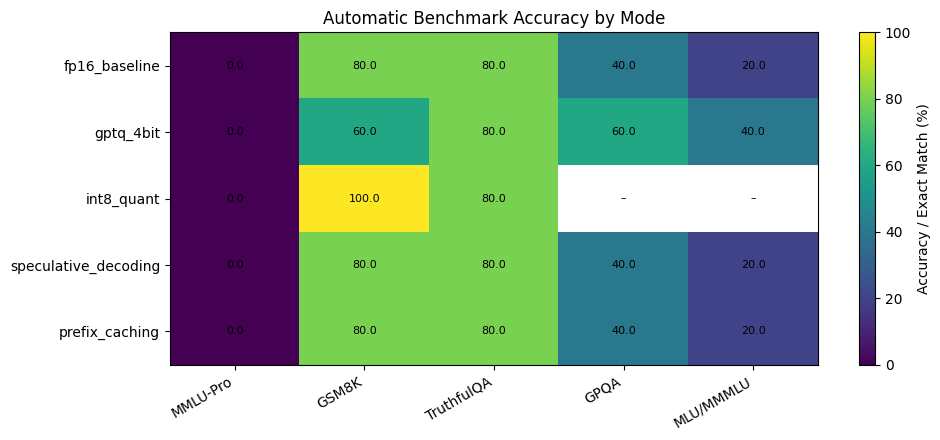

Skipping empty judge plot: MT-Bench-style
Skipping empty judge plot: AlpacaEval-style


In [22]:
# ============================================================
# Cell 17: Separate automatic accuracy and judge-quality plots
# ============================================================

if len(automatic_accuracy_df) > 0:
    automatic_accuracy_matrix = (
        automatic_accuracy_df
        .pivot(index="mode_name", columns="benchmark_label", values="metric_display_value")
        .reindex(
            index=BENCHMARK_MODE_ORDER,
            columns=[
                BENCHMARK_LABELS[w]
                for w in AUTOMATIC_BENCHMARK_DISPLAY_ORDER
                if w in BENCHMARK_LABELS
            ],
        )
    )

    plot_annotated_heatmap(
        automatic_accuracy_matrix,
        title="Automatic Benchmark Accuracy by Mode",
        cbar_label="Accuracy / Exact Match (%)",
        fmt="{:.1f}",
        figsize=(10, 4.5),
        cmap="viridis",
        save_name="automatic_accuracy_heatmap.png",
    )

if len(judge_quality_df) > 0:
    for benchmark_name in JUDGE_BENCHMARK_DISPLAY_ORDER:
        benchmark_label = BENCHMARK_LABELS.get(benchmark_name, benchmark_name)

        sub = (
            judge_quality_df[judge_quality_df["benchmark"] == benchmark_name]
            .set_index("mode_name")
            .reindex(BENCHMARK_MODE_ORDER)
            .reset_index()
        )

        if sub["metric_display_value"].notna().sum() == 0:
            print("Skipping empty judge plot:", benchmark_label)
            continue

        if benchmark_name == "mt_bench_eval":
            ylabel = "Mean judge score"
            ylim = (0, 10)
        else:
            ylabel = "Win rate vs FP16 baseline"
            ylim = (0, 1)

        plot_bar_metric(
            sub,
            x_col="mode_name",
            y_col="metric_display_value",
            title=f"{benchmark_label} Judge Quality by Mode",
            ylabel=ylabel,
            ylim=ylim,
            save_name=f"judge_{benchmark_name}_quality_bar.png",
        )

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/total_latency_heatmap.png


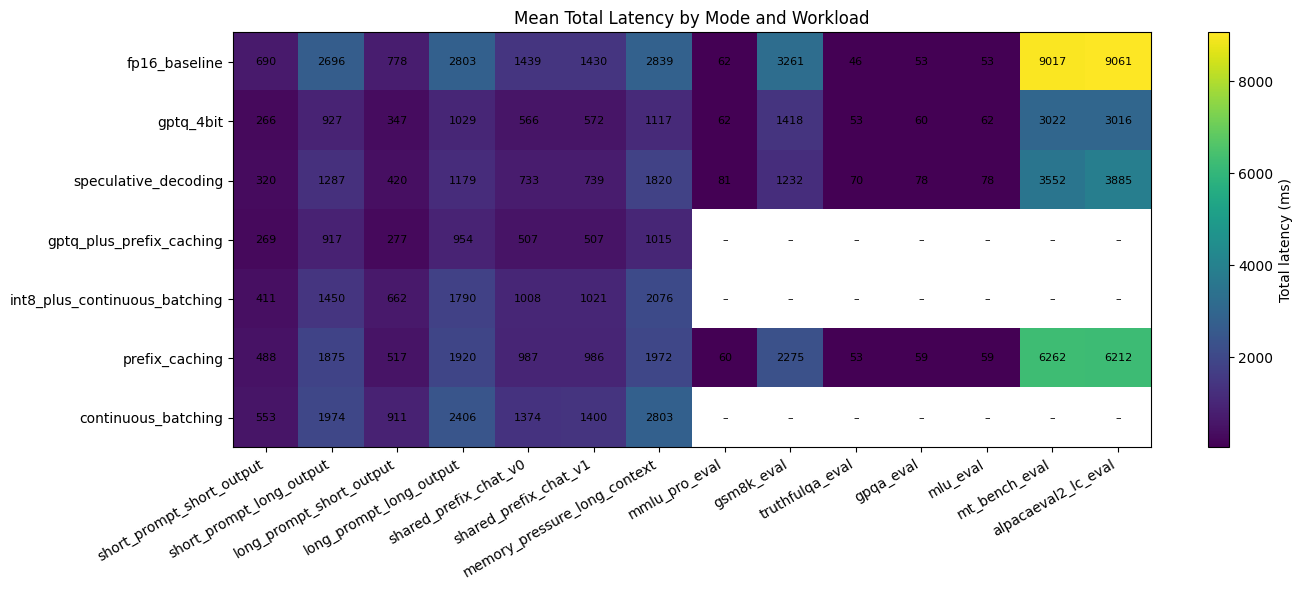

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/throughput_heatmap.png


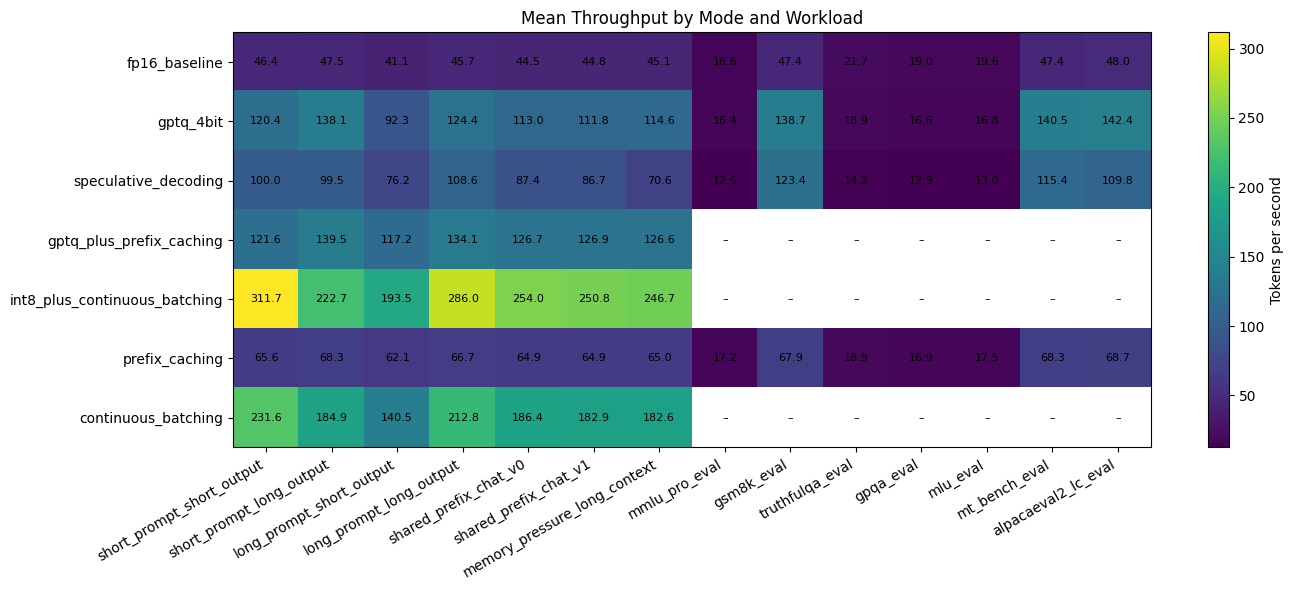

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/energy_per_token_heatmap.png


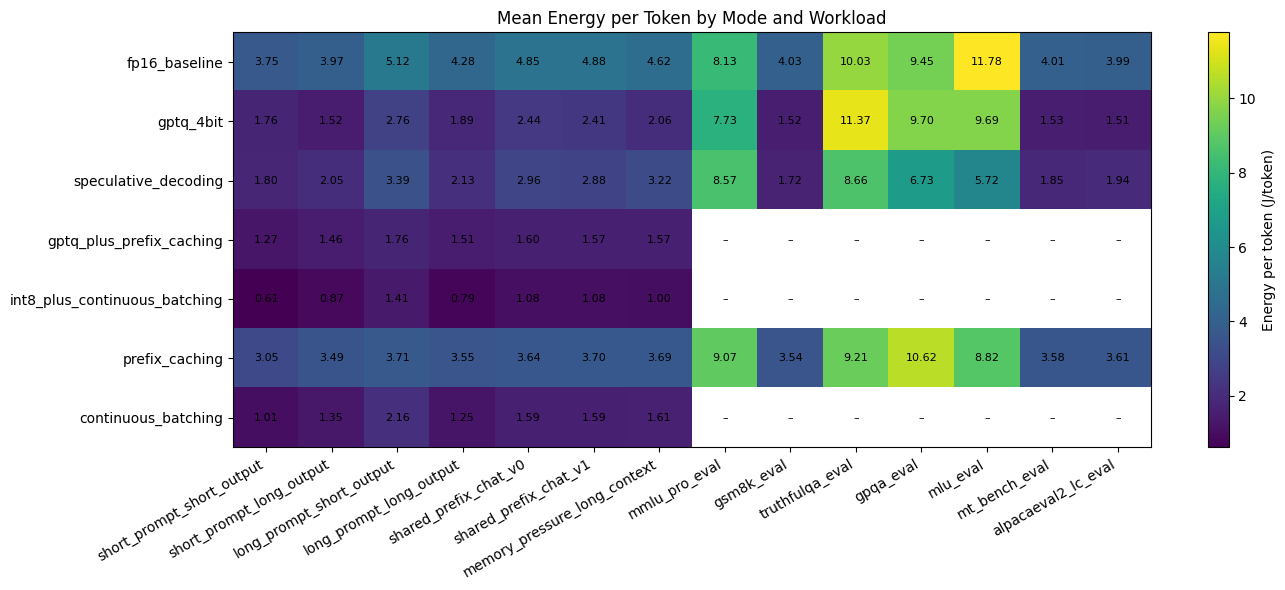

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/peak_gpu_memory_heatmap.png


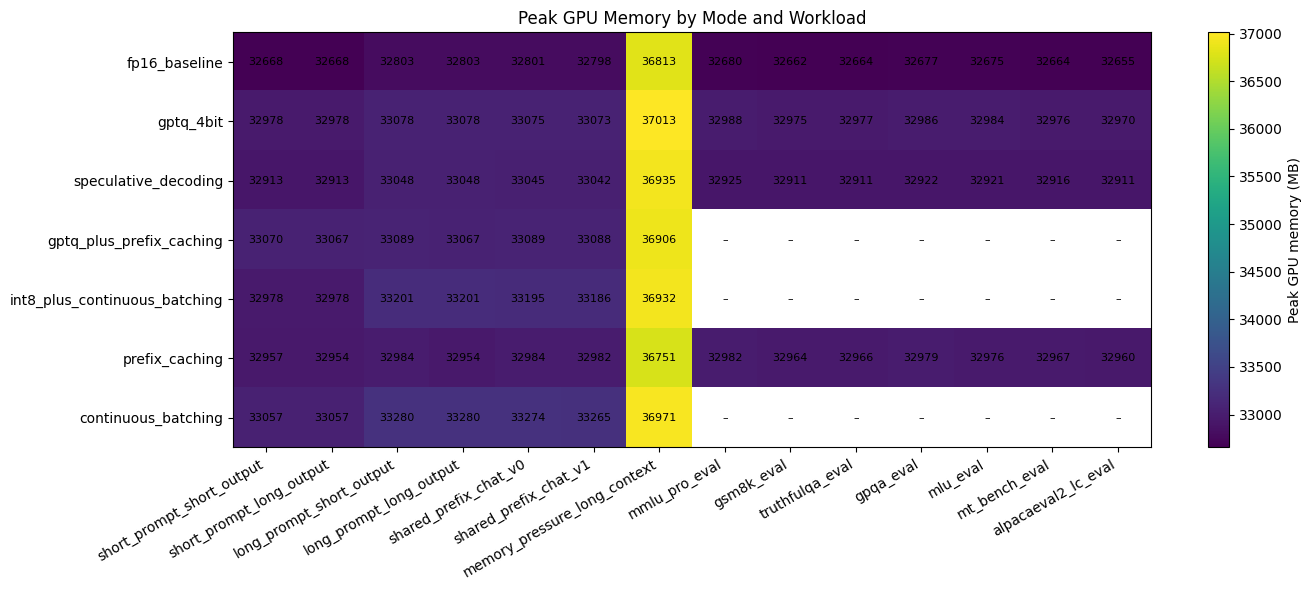

In [23]:
# ============================================================
# Cell 18: Performance heatmaps
# ============================================================

for value_col, title, cbar_label, fmt, save_name in [
    ("total_latency_ms_mean", "Mean Total Latency by Mode and Workload", "Total latency (ms)", "{:.0f}", "total_latency_heatmap.png"),
    ("tokens_per_second_mean", "Mean Throughput by Mode and Workload", "Tokens per second", "{:.1f}", "throughput_heatmap.png"),
    ("energy_per_token_j_mean", "Mean Energy per Token by Mode and Workload", "Energy per token (J/token)", "{:.2f}", "energy_per_token_heatmap.png"),
    ("peak_gpu_memory_mb_mean", "Peak GPU Memory by Mode and Workload", "Peak GPU memory (MB)", "{:.0f}", "peak_gpu_memory_heatmap.png"),
]:
    matrix = (
        dense_agg_df
        .pivot(index="mode_name", columns="workload_name", values=value_col)
        .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
    )

    plot_annotated_heatmap(
        matrix,
        title=title,
        cbar_label=cbar_label,
        fmt=fmt,
        figsize=(14, 6),
        cmap="viridis",
        save_name=save_name,
    )

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/latency_speedup_vs_baseline_heatmap.png


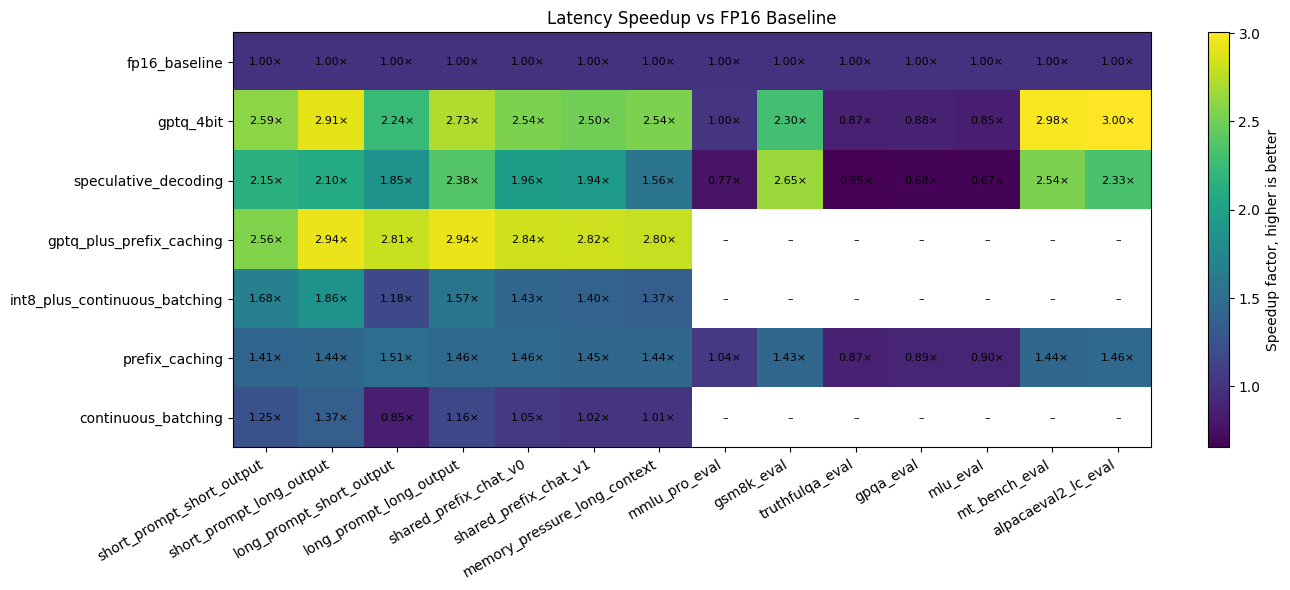

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/energy_ratio_vs_baseline_heatmap.png


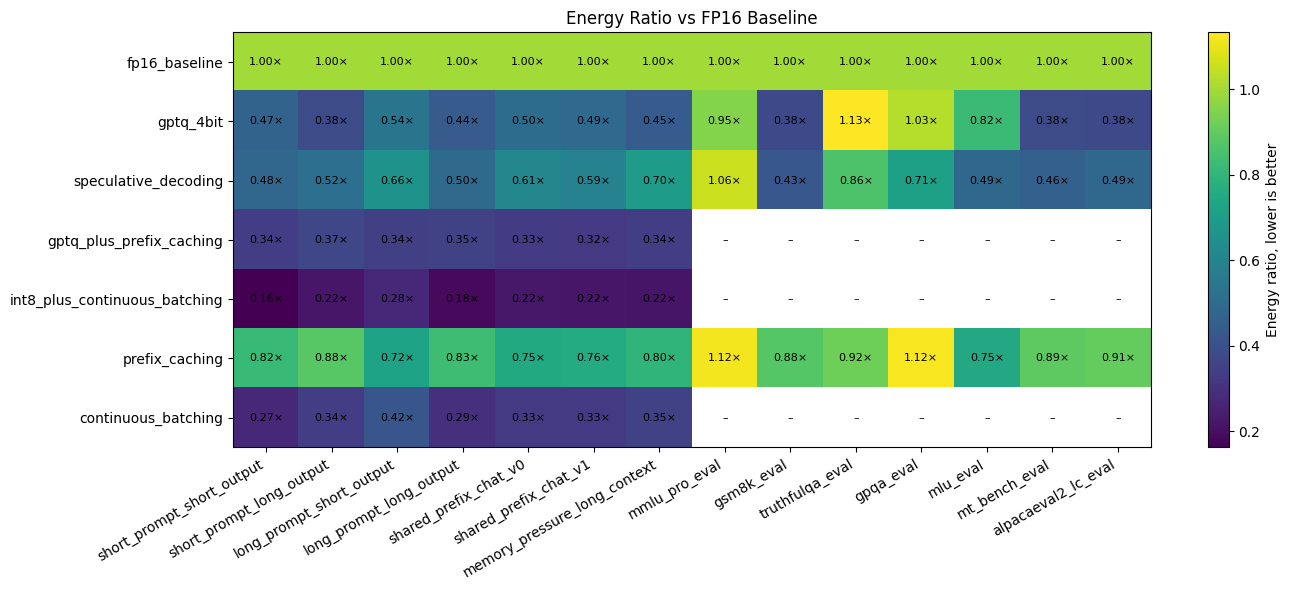

(<Figure size 1400x600 with 2 Axes>,
 <Axes: title={'center': 'Energy Ratio vs FP16 Baseline'}>)

In [24]:
# ============================================================
# Cell 19: Baseline ratio heatmaps
# ============================================================

speedup_matrix = (
    dense_perf_df
    .pivot(index="mode_name", columns="workload_name", values="latency_speedup_vs_baseline")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    speedup_matrix,
    title="Latency Speedup vs FP16 Baseline",
    cbar_label="Speedup factor, higher is better",
    fmt="{:.2f}×",
    figsize=(14, 6),
    cmap="viridis",
    save_name="latency_speedup_vs_baseline_heatmap.png",
)

energy_ratio_matrix = (
    dense_perf_df
    .pivot(index="mode_name", columns="workload_name", values="energy_ratio_vs_baseline")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    energy_ratio_matrix,
    title="Energy Ratio vs FP16 Baseline",
    cbar_label="Energy ratio, lower is better",
    fmt="{:.2f}×",
    figsize=(14, 6),
    cmap="viridis",
    save_name="energy_ratio_vs_baseline_heatmap.png",
)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/prefill_share_heatmap.png


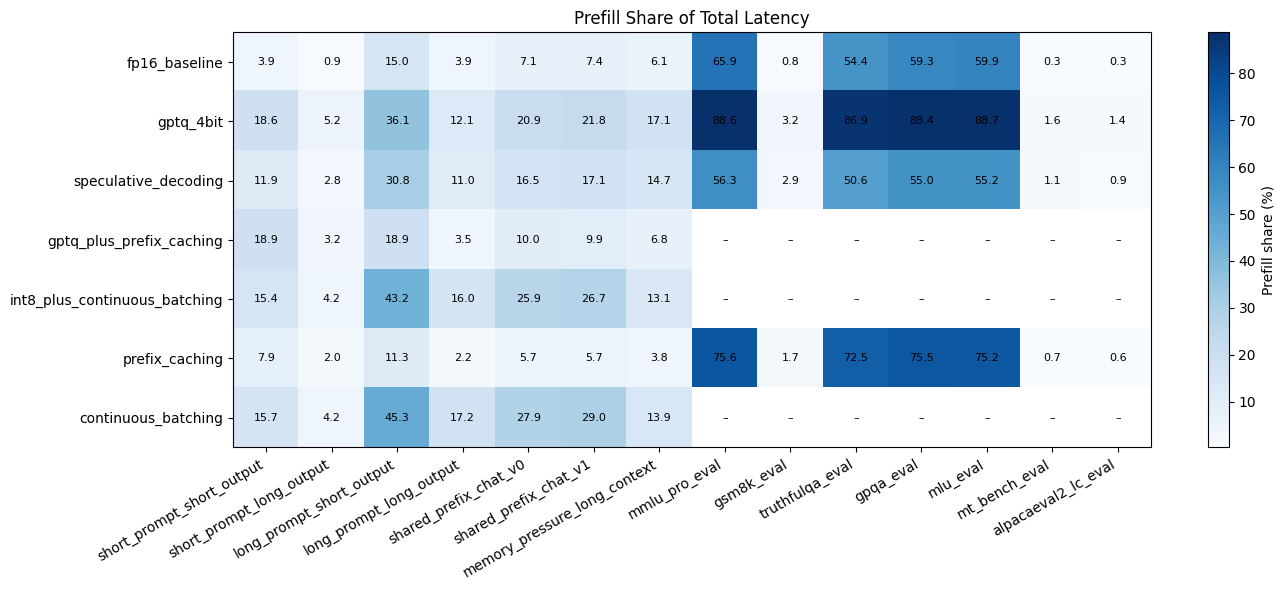

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/decode_share_heatmap.png


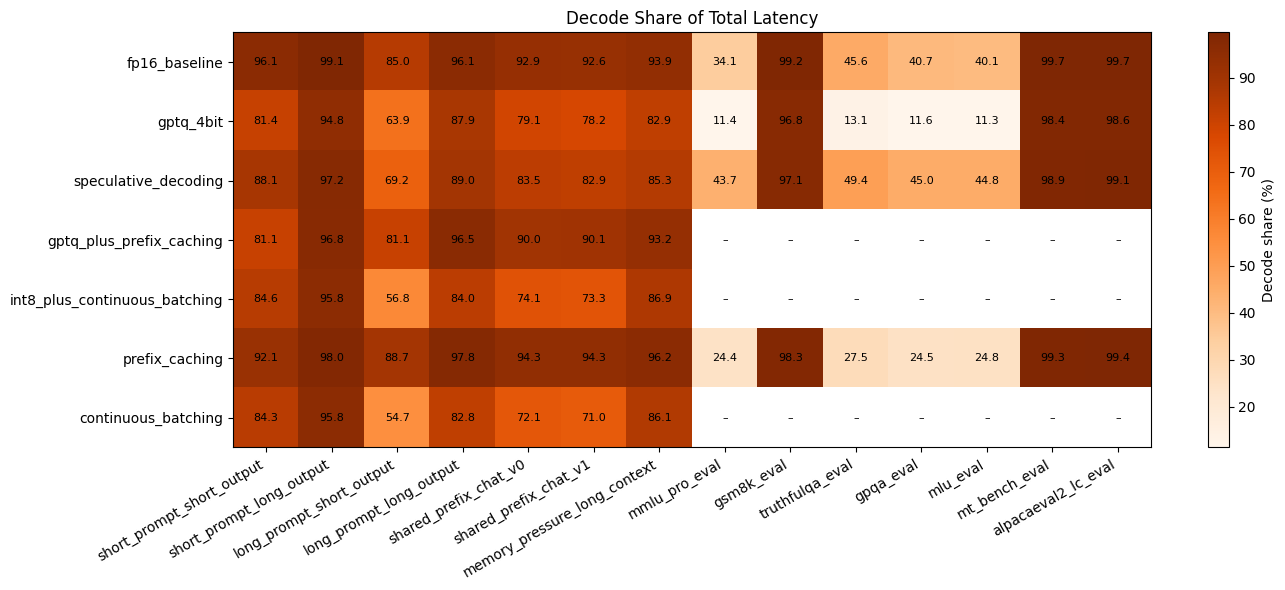

(<Figure size 1400x600 with 2 Axes>,
 <Axes: title={'center': 'Decode Share of Total Latency'}>)

In [25]:
# ============================================================
# Cell 20: Phase dominance heatmaps
# ============================================================

prefill_matrix = (
    dense_phase_df
    .pivot(index="mode_name", columns="workload_name", values="prefill_pct")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

decode_matrix = (
    dense_phase_df
    .pivot(index="mode_name", columns="workload_name", values="decode_pct")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    prefill_matrix,
    title="Prefill Share of Total Latency",
    cbar_label="Prefill share (%)",
    fmt="{:.1f}",
    figsize=(14, 6),
    cmap="Blues",
    save_name="prefill_share_heatmap.png",
)

plot_annotated_heatmap(
    decode_matrix,
    title="Decode Share of Total Latency",
    cbar_label="Decode share (%)",
    fmt="{:.1f}",
    figsize=(14, 6),
    cmap="Oranges",
    save_name="decode_share_heatmap.png",
)

In [26]:
# ============================================================
# Cell 21: Best mode tables
# ============================================================

best_latency_df = (
    dense_perf_df
    .sort_values(["workload_name", "total_latency_ms_mean"])
    .groupby("workload_name", as_index=False)
    .first()
)

best_energy_df = (
    dense_perf_df
    .sort_values(["workload_name", "energy_per_token_j_mean"])
    .groupby("workload_name", as_index=False)
    .first()
)

best_throughput_df = (
    dense_perf_df
    .sort_values(["workload_name", "tokens_per_second_mean"], ascending=[True, False])
    .groupby("workload_name", as_index=False)
    .first()
)

best_latency_df = best_latency_df[
    [
        "workload_name",
        "mode_name",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "energy_ratio_vs_baseline",
        "peak_gpu_memory_mb_mean",
    ]
]

best_energy_df = best_energy_df[
    [
        "workload_name",
        "mode_name",
        "energy_per_token_j_mean",
        "energy_ratio_vs_baseline",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "tokens_per_second_mean",
        "peak_gpu_memory_mb_mean",
    ]
]

best_throughput_df = best_throughput_df[
    [
        "workload_name",
        "mode_name",
        "tokens_per_second_mean",
        "throughput_ratio_vs_baseline",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]
]

save_table(best_latency_df, "best_mode_by_latency.csv")
save_table(best_energy_df, "best_mode_by_energy.csv")
save_table(best_throughput_df, "best_mode_by_throughput.csv")

print("Best by latency:")
display(best_latency_df)

print("Best by energy:")
display(best_energy_df)

print("Best by throughput:")
display(best_throughput_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260428_134440/best_mode_by_latency.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260428_134440/best_mode_by_energy.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260428_134440/best_mode_by_throughput.csv
Best by latency:


,workload_name,mode_name,total_latency_ms_mean,latency_speedup_vs_baseline,tokens_per_second_mean,energy_per_token_j_mean,energy_ratio_vs_baseline,peak_gpu_memory_mb_mean
0,alpacaeval2_lc_eval,gptq_4bit,3015.588723,3.004851,142.440957,1.505323,0.377262,32969.785645
1,gpqa_eval,fp16_baseline,52.991658,1.000000,18.988560,9.445776,1.000000,32676.939453
2,gsm8k_eval,speculative_decoding,1231.565072,2.648170,123.434240,1.718271,0.425977,32910.989746
3,long_prompt_long_output,gptq_plus_prefix_caching,954.173160,2.937663,134.147736,1.514081,0.354097,33066.589355
4,long_prompt_short_output,gptq_plus_prefix_caching,277.433448,2.805862,117.236623,1.764550,0.344860,33089.345801
5,memory_pressure_long_context,gptq_plus_prefix_caching,1015.090842,2.796640,126.558084,1.569389,0.339860,36906.163770
6,mlu_eval,fp16_baseline,52.535219,1.000000,19.588314,11.780291,1.000000,32674.839941
7,mmlu_pro_eval,int8_quant,51.551425,1.209687,19.811163,6.351850,0.781620,32982.493262
8,mt_bench_eval,gptq_4bit,3022.025202,2.983708,140.530113,1.534625,0.382353,32976.153027
9,shared_prefix_chat_v0,gptq_plus_prefix_caching,507.121678,2.837963,126.724139,1.604936,0.331095,33089.470801


Best by energy:


,workload_name,mode_name,energy_per_token_j_mean,energy_ratio_vs_baseline,total_latency_ms_mean,latency_speedup_vs_baseline,tokens_per_second_mean,peak_gpu_memory_mb_mean
0,alpacaeval2_lc_eval,gptq_4bit,1.505323,0.377262,3015.588723,3.004851,142.440957,32969.785645
1,gpqa_eval,speculative_decoding,6.727360,0.712208,77.806770,0.681067,12.889818,32922.059863
2,gsm8k_eval,gptq_4bit,1.524829,0.378021,1418.242848,2.299602,138.658776,32975.423047
3,long_prompt_long_output,int8_plus_continuous_batching,0.789684,0.184683,1790.402906,1.565592,285.970322,33201.403809
4,long_prompt_short_output,int8_plus_continuous_batching,1.408516,0.275277,661.502769,1.176775,193.499308,33201.403809
5,memory_pressure_long_context,int8_plus_continuous_batching,1.000880,0.216746,2075.552198,1.367753,246.681481,36931.971680
6,mlu_eval,speculative_decoding,5.721660,0.485698,77.990717,0.673609,13.015898,32920.733984
7,mmlu_pro_eval,int8_quant,6.351850,0.781620,51.551425,1.209687,19.811163,32982.493262
8,mt_bench_eval,gptq_4bit,1.534625,0.382353,3022.025202,2.983708,140.530113,32976.153027
9,shared_prefix_chat_v0,int8_plus_continuous_batching,1.080819,0.222971,1007.733242,1.428148,254.035685,33195.213379


Best by throughput:


,workload_name,mode_name,tokens_per_second_mean,throughput_ratio_vs_baseline,total_latency_ms_mean,latency_speedup_vs_baseline,energy_per_token_j_mean,peak_gpu_memory_mb_mean
0,alpacaeval2_lc_eval,gptq_4bit,142.440957,2.970494,3015.588723,3.004851,1.505323,32969.785645
1,gpqa_eval,fp16_baseline,18.988560,1.000000,52.991658,1.000000,9.445776,32676.939453
2,gsm8k_eval,gptq_4bit,138.658776,2.926493,1418.242848,2.299602,1.524829,32975.423047
3,long_prompt_long_output,int8_plus_continuous_batching,285.970322,6.262206,1790.402906,1.565592,0.789684,33201.403809
4,long_prompt_short_output,int8_plus_continuous_batching,193.499308,4.705790,661.502769,1.176775,1.408516,33201.403809
5,memory_pressure_long_context,int8_plus_continuous_batching,246.681481,5.470854,2075.552198,1.367753,1.000880,36931.971680
6,mlu_eval,fp16_baseline,19.588314,1.000000,52.535219,1.000000,11.780291,32674.839941
7,mmlu_pro_eval,int8_quant,19.811163,1.193682,51.551425,1.209687,6.351850,32982.493262
8,mt_bench_eval,gptq_4bit,140.530113,2.965570,3022.025202,2.983708,1.534625,32976.153027
9,shared_prefix_chat_v0,int8_plus_continuous_batching,254.035685,5.711365,1007.733242,1.428148,1.080819,33195.213379


In [28]:
# ============================================================
# Cell 22: List saved plots and tables
# ============================================================

print("Saved plots:")
for path in sorted(PLOT_DIR.glob("*")):
    print(" -", path)

print("\nSaved tables:")
for path in sorted(TABLE_DIR.glob("*")):
    print(" -", path)

print("\nFinal dense result files:")
maybe_paths = [
    globals().get("dense_json_path"),
    globals().get("dense_csv_path"),
    globals().get("dense_summary_csv_path"),
    globals().get("dense_aggregate_csv_path"),
    globals().get("dense_comparison_csv_path"),
    globals().get("dense_error_csv_path"),
    globals().get("dense_report_dir"),
    globals().get("judge_sidecar_path"),
]

for path in maybe_paths:
    if path is not None:
        print(" -", path)

Saved plots:
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/automatic_accuracy_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/decode_share_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/energy_per_token_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/energy_ratio_vs_baseline_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/latency_speedup_vs_baseline_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/peak_gpu_memory_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260428_134440/prefill_share_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_202

In [ ]:
1